In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings

warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('insurance.csv')

In [3]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


# EDA

In [4]:
df.shape

(1338, 7)

In [5]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [7]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [8]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

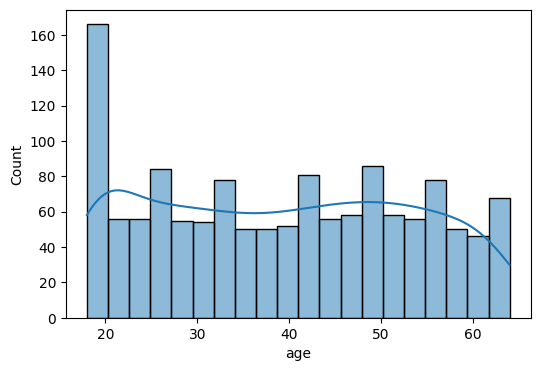

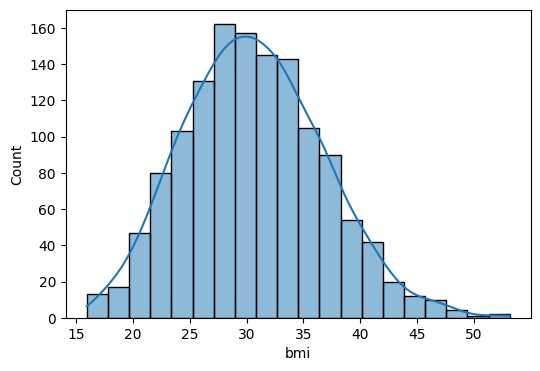

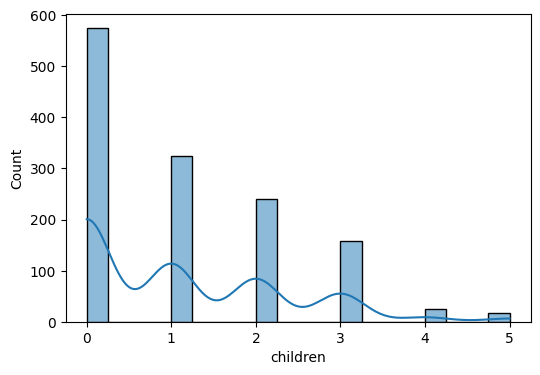

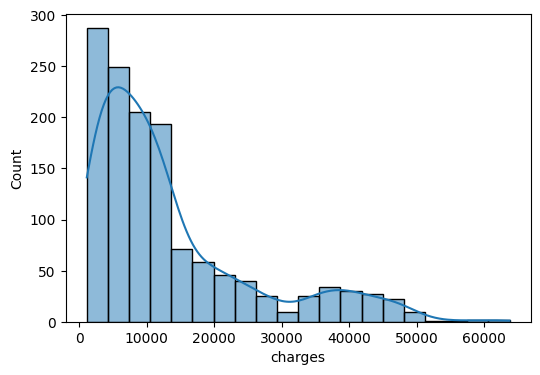

In [9]:
numeric_cols=['age','bmi','children','charges']
for cols in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[cols],kde=True,bins=20)

<Axes: xlabel='children', ylabel='count'>

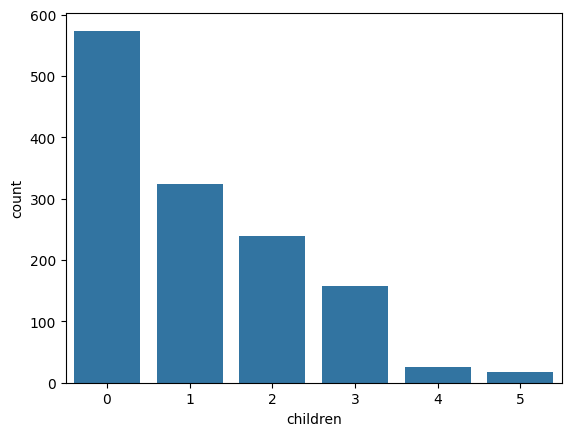

In [10]:
sns.countplot(x=df['children'])

<Axes: xlabel='sex', ylabel='count'>

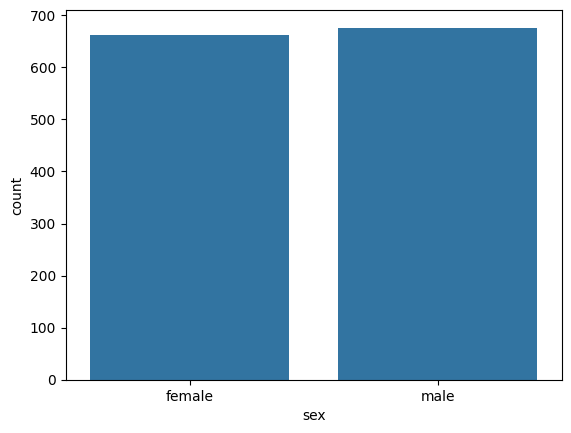

In [11]:
sns.countplot(x=df['sex'])

<Axes: xlabel='smoker', ylabel='count'>

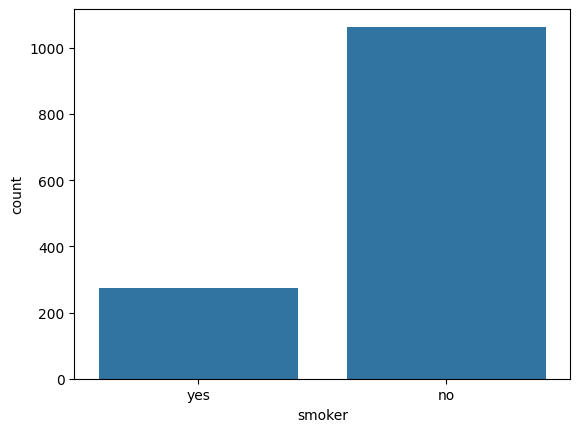

In [12]:
sns.countplot(x=df['smoker'])

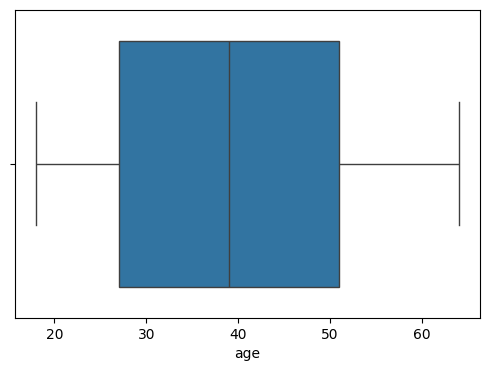

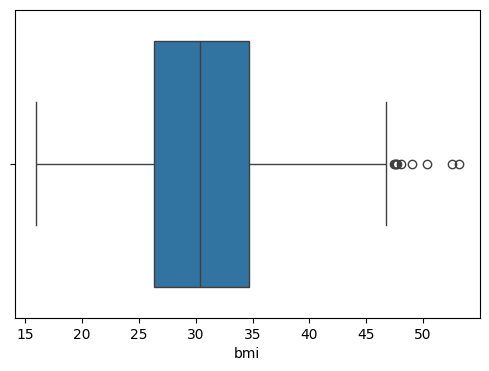

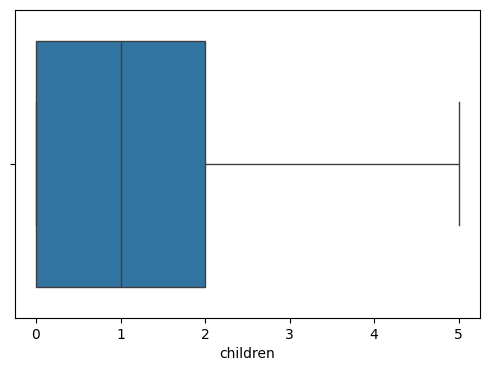

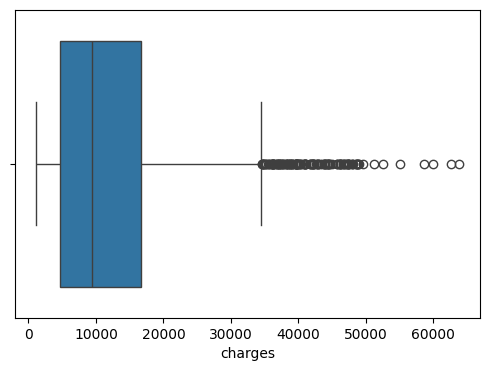

In [13]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])

In [14]:
df.corr(numeric_only=True)

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


<Axes: >

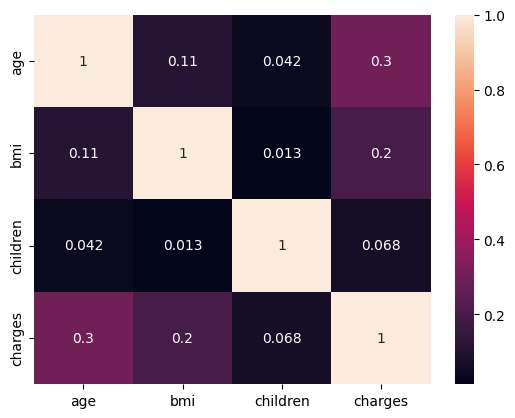

In [15]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

# Data Cleaning

In [16]:
df_cleaned=df.copy()

In [17]:
df_cleaned

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [18]:
df_cleaned.duplicated().sum()

np.int64(1)

There is one duplicate row

In [19]:
df_cleaned.shape

(1338, 7)

In [20]:
df_cleaned.drop_duplicates(inplace=True)

In [21]:
df_cleaned.shape

(1337, 7)

# Preprocessing

In [22]:
df_cleaned.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [23]:
df_cleaned['sex'].unique()

<ArrowStringArray>
['female', 'male']
Length: 2, dtype: str

In [24]:
df_cleaned['sex'] = df_cleaned['sex'].map({'male':0,'female':1})

In [25]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [26]:
df_cleaned['smoker'].unique()

<ArrowStringArray>
['yes', 'no']
Length: 2, dtype: str

In [27]:
df_cleaned['smoker'] = df_cleaned['smoker'].map({'yes':1,'no':0})

In [28]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [29]:
df_cleaned.rename(columns={
    'sex':'is_female',
    'smoker':'is_smoker'
},inplace=True)

In [30]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [31]:
df_cleaned['region'].unique()

<ArrowStringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str

In [32]:
df_cleaned = pd.get_dummies(df_cleaned,columns=['region'])

In [33]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,False,True
1,18,0,33.770,1,0,1725.55230,False,False,True,False
2,28,0,33.000,3,0,4449.46200,False,False,True,False
3,33,0,22.705,0,0,21984.47061,False,True,False,False
4,32,0,28.880,0,0,3866.85520,False,True,False,False


In [34]:
df_cleaned[['region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']] = df_cleaned[['region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']].astype(int)

In [35]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,0,0,0,1
1,18,0,33.770,1,0,1725.55230,0,0,1,0
2,28,0,33.000,3,0,4449.46200,0,0,1,0
3,33,0,22.705,0,0,21984.47061,0,1,0,0
4,32,0,28.880,0,0,3866.85520,0,1,0,0


In [36]:
df_cleaned.dtypes

age                   int64
is_female             int64
bmi                 float64
children              int64
is_smoker             int64
charges             float64
region_northeast      int64
region_northwest      int64
region_southeast      int64
region_southwest      int64
dtype: object

# Feature Engineering and Encoding

In [37]:
df_cleaned['bmi_category'] = pd.cut(
    df_cleaned['bmi'],
    bins=[0,18.9,24.9,29.9,float('inf')],
    labels=['Underweight','Normal','Overweight','Obese']
)

In [38]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27.900,0,1,16884.92400,0,0,0,1,Overweight
1,18,0,33.770,1,0,1725.55230,0,0,1,0,Obese
2,28,0,33.000,3,0,4449.46200,0,0,1,0,Obese
3,33,0,22.705,0,0,21984.47061,0,1,0,0,Normal
4,32,0,28.880,0,0,3866.85520,0,1,0,0,Overweight
...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,0,1,0,0,Obese
1334,18,1,31.920,0,0,2205.98080,1,0,0,0,Obese
1335,18,1,36.850,0,0,1629.83350,0,0,1,0,Obese
1336,21,1,25.800,0,0,2007.94500,0,0,0,1,Overweight


In [39]:
df_cleaned['age_category']= pd.cut(
    df_cleaned['age'],
    bins=[0,18,60,80,float('inf')], 
    labels=["UnderAged","Young","Adult","Old"]
)

In [40]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category,age_category
0,19,1,27.900,0,1,16884.92400,0,0,0,1,Overweight,Young
1,18,0,33.770,1,0,1725.55230,0,0,1,0,Obese,UnderAged
2,28,0,33.000,3,0,4449.46200,0,0,1,0,Obese,Young
3,33,0,22.705,0,0,21984.47061,0,1,0,0,Normal,Young
4,32,0,28.880,0,0,3866.85520,0,1,0,0,Overweight,Young
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,0,1,0,0,Obese,Young
1334,18,1,31.920,0,0,2205.98080,1,0,0,0,Obese,UnderAged
1335,18,1,36.850,0,0,1629.83350,0,0,1,0,Obese,UnderAged
1336,21,1,25.800,0,0,2007.94500,0,0,0,1,Overweight,Young


In [41]:
df_cleaned=pd.get_dummies(df_cleaned,columns=['bmi_category','age_category'])

In [42]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_Underweight,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese,age_category_UnderAged,age_category_Young,age_category_Adult,age_category_Old
0,19,1,27.900,0,1,16884.92400,0,0,0,1,False,False,True,False,False,True,False,False
1,18,0,33.770,1,0,1725.55230,0,0,1,0,False,False,False,True,True,False,False,False
2,28,0,33.000,3,0,4449.46200,0,0,1,0,False,False,False,True,False,True,False,False
3,33,0,22.705,0,0,21984.47061,0,1,0,0,False,True,False,False,False,True,False,False
4,32,0,28.880,0,0,3866.85520,0,1,0,0,False,False,True,False,False,True,False,False


In [46]:
df_cleaned[['bmi_category_Underweight','bmi_category_Normal','bmi_category_Overweight','bmi_category_Obese','age_category_UnderAged','age_category_Young','age_category_Adult','age_category_Old']]=df_cleaned[['bmi_category_Underweight','bmi_category_Normal','bmi_category_Overweight','bmi_category_Obese','age_category_UnderAged','age_category_Young','age_category_Adult','age_category_Old']].astype(int)

In [47]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_Underweight,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese,age_category_UnderAged,age_category_Young,age_category_Adult,age_category_Old
0,19,1,27.900,0,1,16884.92400,0,0,0,1,0,0,1,0,0,1,0,0
1,18,0,33.770,1,0,1725.55230,0,0,1,0,0,0,0,1,1,0,0,0
2,28,0,33.000,3,0,4449.46200,0,0,1,0,0,0,0,1,0,1,0,0
3,33,0,22.705,0,0,21984.47061,0,1,0,0,0,1,0,0,0,1,0,0
4,32,0,28.880,0,0,3866.85520,0,1,0,0,0,0,1,0,0,1,0,0


In [48]:
df_cleaned.shape

(1337, 18)

<Axes: >

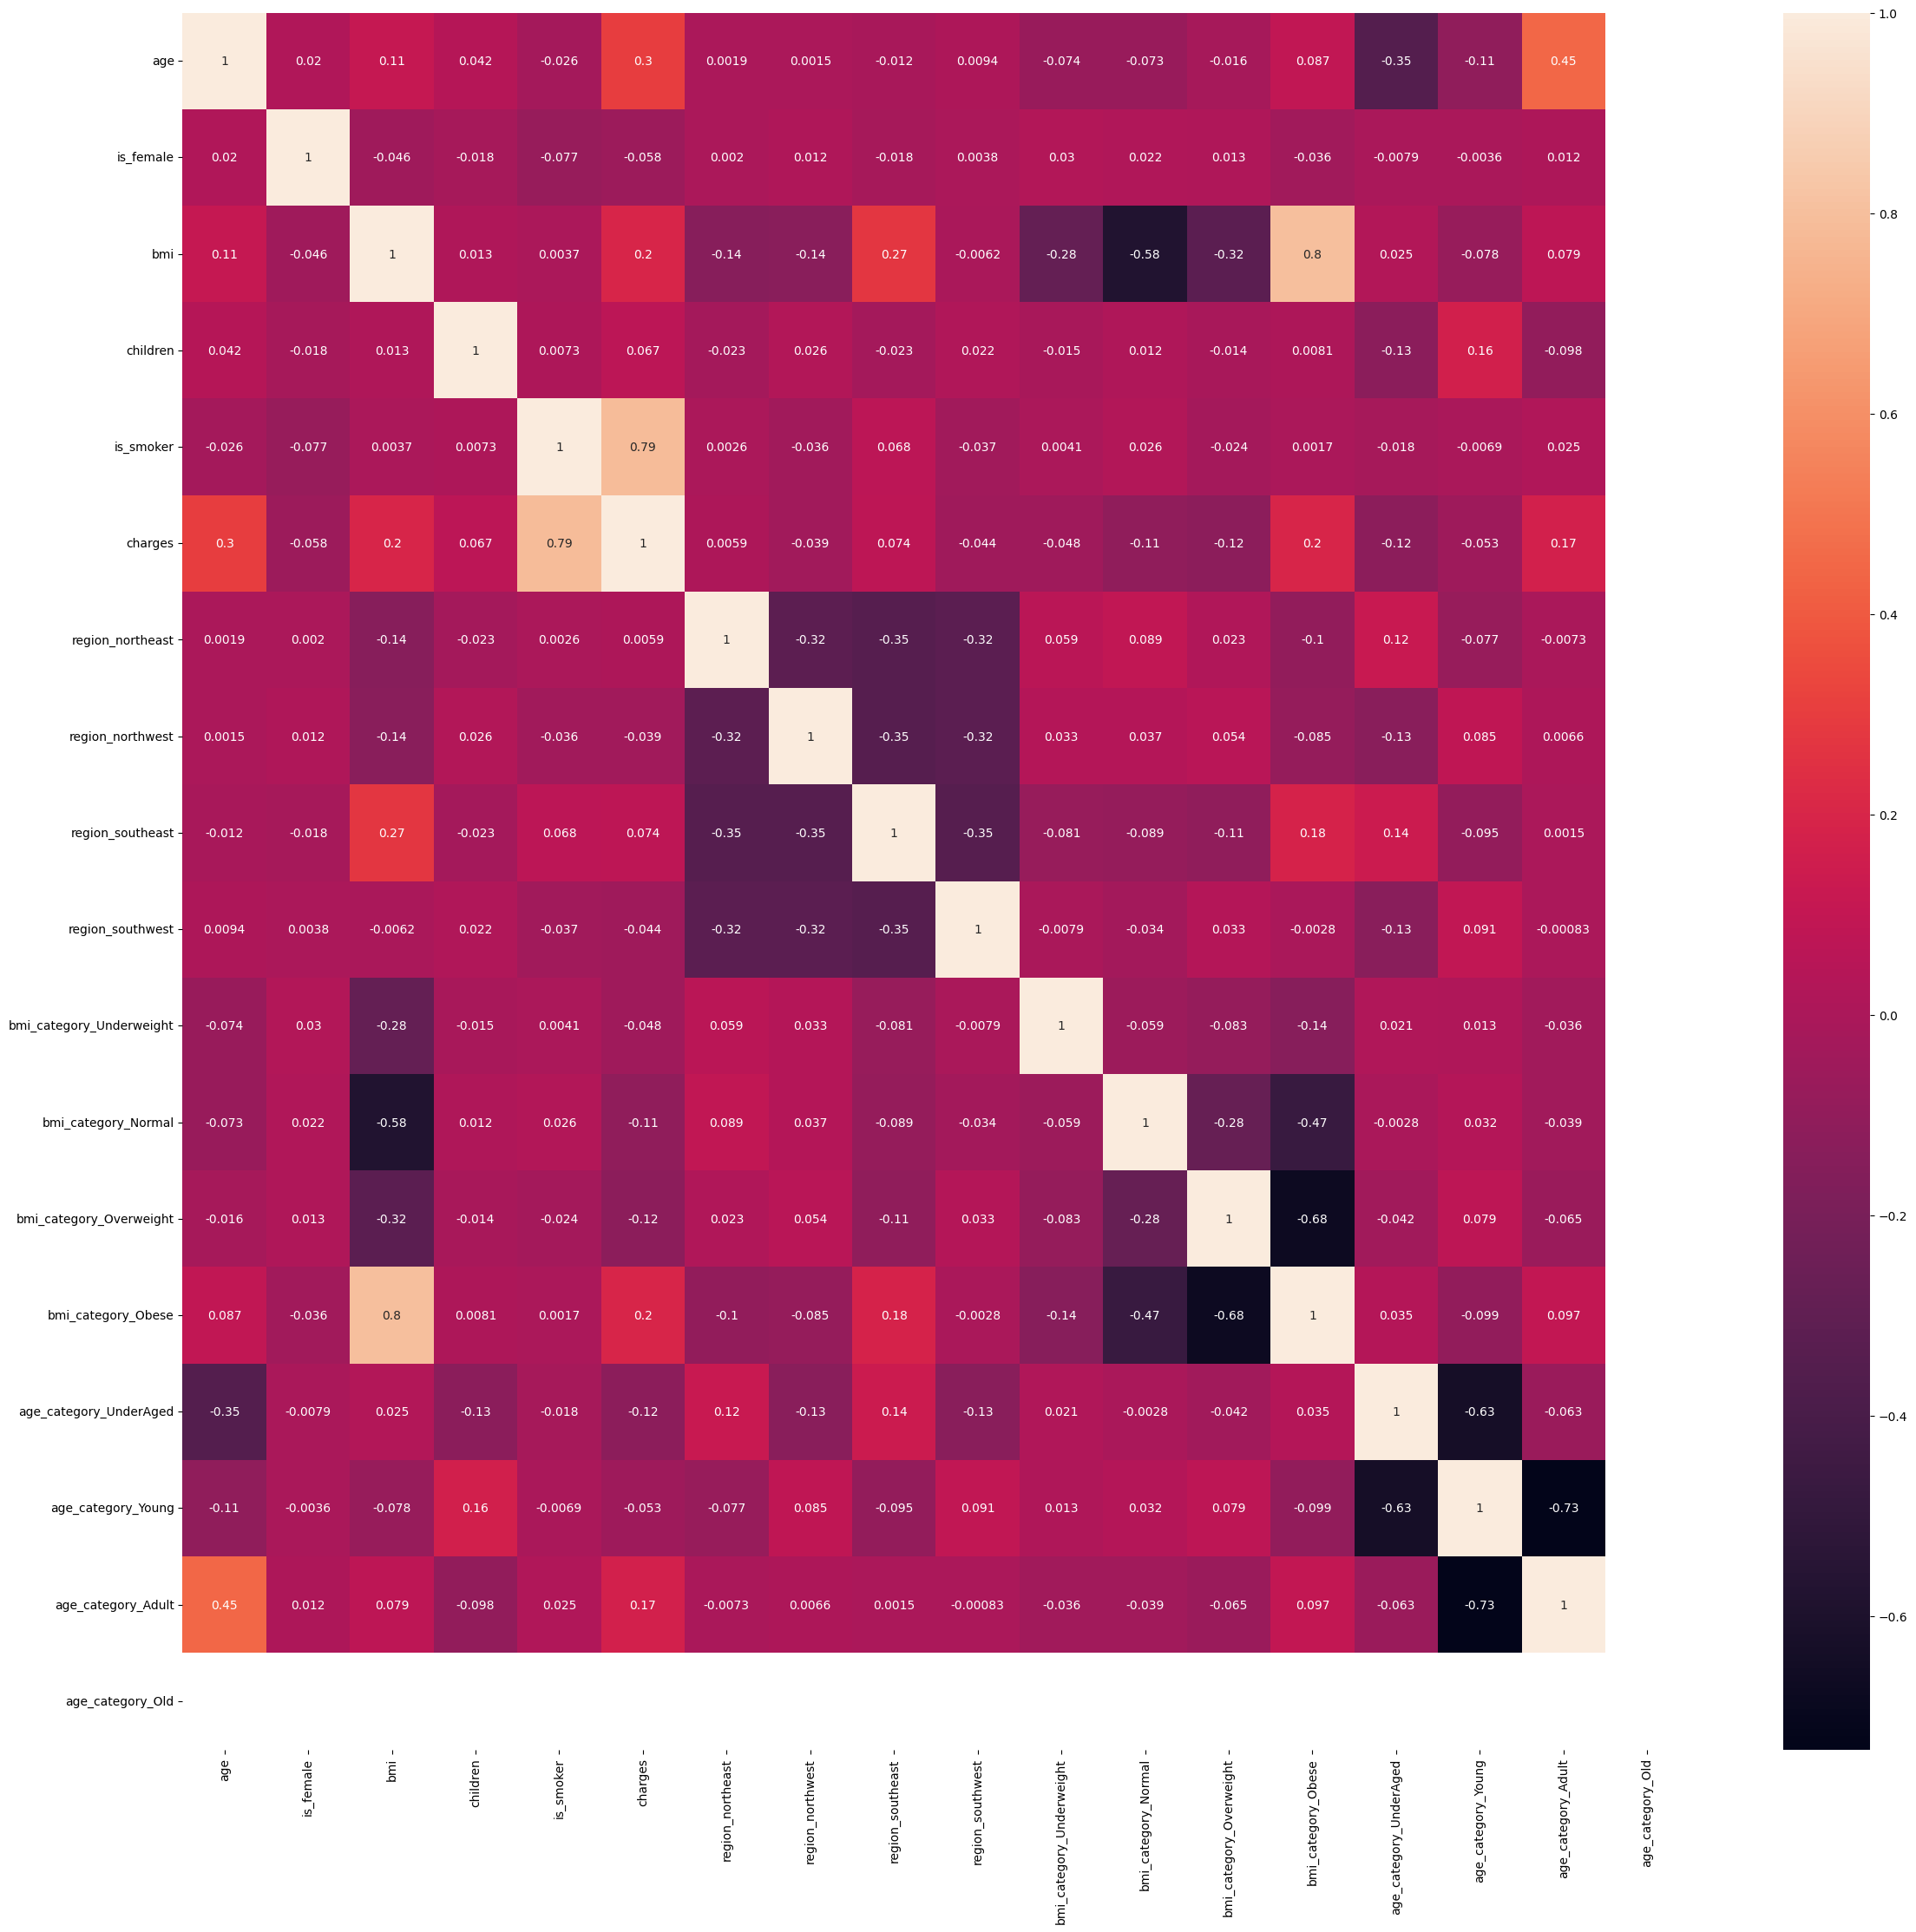

In [54]:
plt.figure(figsize=(28,26))
sns.heatmap(df_cleaned.corr(numeric_only=True),annot=True)